# Brain Tumor Classification — EfficientNet-B0


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import efficientnet_b0

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import sys


## Config

In [2]:
DATASET_PATH = Path(r"C:\Users\Emine Rae\Desktop\Brain Tumor MRI Dataset")
TRAIN_PATH = DATASET_PATH / "classification_task" / "train"
TEST_PATH = DATASET_PATH / "classification_task" / "test"

CLASSES = ["glioma", "meningioma", "no_tumor", "pituitary"]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
MODEL_PATH = "best_efficientnet_b0.pth"

print("Python Executable Path:", sys.executable)
print("PyTorch Version Installed:", torch.__version__)
print("Is CUDA framework layer detected?:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("SUCCESS! Using GPU:", torch.cuda.get_device_name(0))
else:
    print(" FAILED. PyTorch is still reading a CPU-only build.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Python Executable Path: c:\Program Files\Python310\python.exe
PyTorch Version Installed: 2.13.0+cu126
Is CUDA framework layer detected?: True
SUCCESS! Using GPU: NVIDIA GeForce GTX 1650


## Transforms

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Dataset

In [4]:
class BrainTumorDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)
        return image, label


def collect_image_paths(root, classes):
    valid_ext = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_paths, labels = [], []
    for class_index, class_name in enumerate(classes):
        for image_path in (root / class_name).iterdir():
            if image_path.suffix.lower() in valid_ext:
                image_paths.append(str(image_path))
                labels.append(class_index)
    return image_paths, labels

## Train / validation split

In [5]:
image_paths, labels = collect_image_paths(TRAIN_PATH, CLASSES)

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Train      :", len(X_train))
print("Validation :", len(X_val))

Train      : 4000
Validation : 1000


## Datasets & loaders

In [6]:
train_dataset = BrainTumorDataset(X_train, y_train, transform=train_transform)
val_dataset = BrainTumorDataset(X_val, y_val, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_image_paths, test_labels = collect_image_paths(TEST_PATH, CLASSES)
test_dataset = BrainTumorDataset(test_image_paths, test_labels, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Test images:", len(test_dataset))

Test images: 1000


## Model preparation

In [7]:
model = efficientnet_b0(weights="DEFAULT" if not Path(MODEL_PATH).exists() else None)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, len(CLASSES))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, correct / total

## Train (skipped automatically if a saved model already exists)

In [9]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

if Path(MODEL_PATH).exists():
    print(f"Found existing model at '{MODEL_PATH}' — skipping training and loading it.")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model = model.to(device)

else:
    print("No saved model found — starting training.")
    best_val_loss = float("inf")

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(
            f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
            f"| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), MODEL_PATH)
            print("  \u2713 Best model saved")

model.eval()

Found existing model at 'best_efficientnet_b0.pth' — skipping training and loading it.


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

## Training curves


In [10]:
if train_losses:
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()
    plt.savefig('Training vs Validation Loss.png')

    plt.figure(figsize=(8, 5))
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.show()
    plt.savefig('Training vs Validation Accuracy.png')

else:
    print("No training history to plot (model was loaded from disk).")

No training history to plot (model was loaded from disk).


## Test evaluation

In [11]:
all_predictions, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_predictions)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

print(classification_report(all_labels, all_predictions, target_names=CLASSES, digits=4))

Test Accuracy: 99.00%
              precision    recall  f1-score   support

      glioma     0.9881    0.9843    0.9862       254
  meningioma     0.9805    0.9869    0.9837       306
    no_tumor     1.0000    1.0000    1.0000       140
   pituitary     0.9967    0.9933    0.9950       300

    accuracy                         0.9900      1000
   macro avg     0.9913    0.9911    0.9912      1000
weighted avg     0.9900    0.9900    0.9900      1000



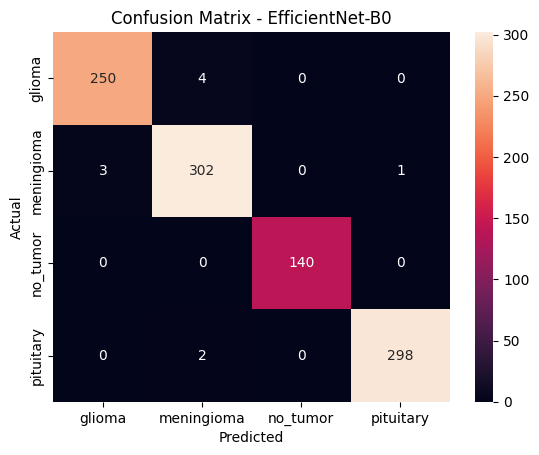

<Figure size 640x480 with 0 Axes>

In [12]:
cm = confusion_matrix(all_labels, all_predictions)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNet-B0")
plt.show()
plt.savefig('confusion_matrix.png')


## Misclassified examples

Wrong predictions: 10


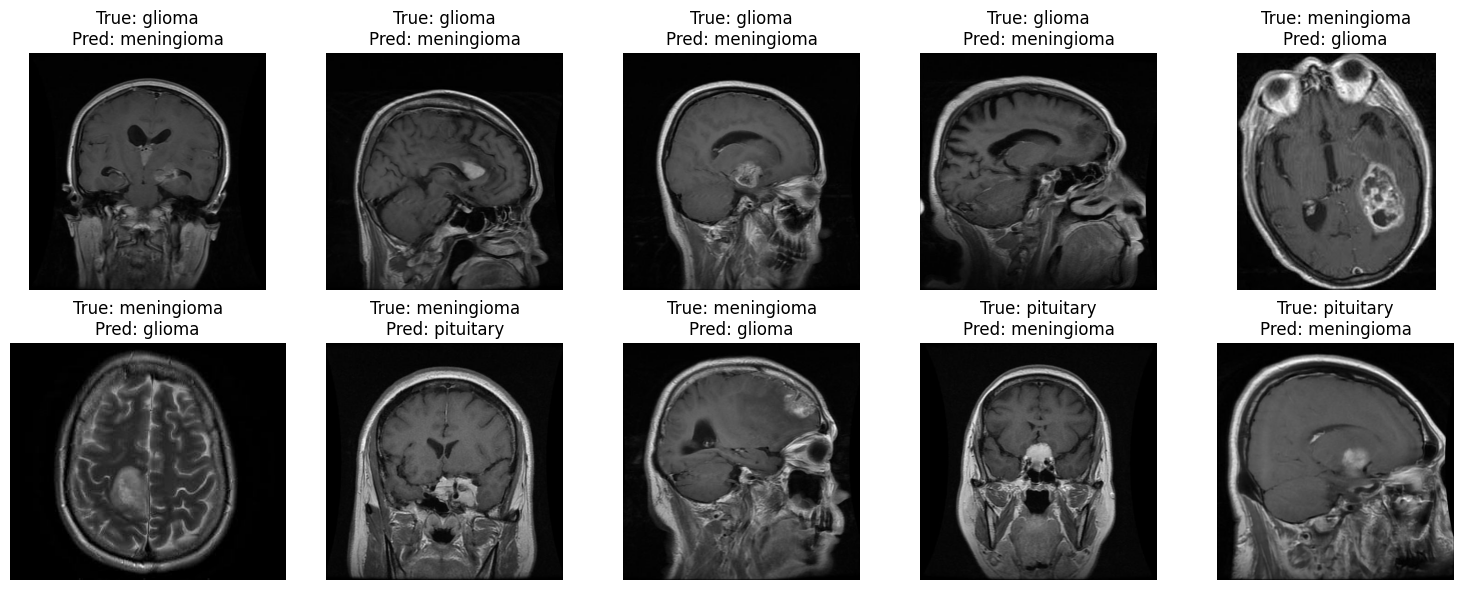

In [13]:
wrong_indices = [i for i in range(len(all_labels)) if all_labels[i] != all_predictions[i]]
print("Wrong predictions:", len(wrong_indices))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, index in zip(axes.flat, wrong_indices[:10]):
    image = Image.open(test_image_paths[index]).convert("RGB")
    ax.imshow(image)
    ax.set_title(f"True: {CLASSES[all_labels[index]]}\nPred: {CLASSES[all_predictions[index]]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Grad-CAM

In [14]:
target_layer = model.features[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

def show_gradcam(model, image_path, transform, class_names, cam):
    original_image = Image.open(image_path).convert("RGB")
    input_tensor = transform(original_image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    predicted_class = torch.argmax(output, dim=1).item()
    confidence = torch.softmax(output, dim=1)[0][predicted_class].item() * 100

    targets = [ClassifierOutputTarget(predicted_class)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    image_resized = original_image.resize((IMG_SIZE, IMG_SIZE))
    rgb_image = np.array(image_resized).astype(np.float32) / 255.0
    visualization = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.title("Original MRI")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(grayscale_cam, cmap="jet")
    plt.title(f"Grad-CAM\n{class_names[predicted_class]}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(visualization)
    plt.title(f"Prediction: {class_names[predicted_class]}\nConfidence: {confidence:.2f}%")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Nombre total d'images correctement prédites : 990
True: no_tumor | Predicted: no_tumor


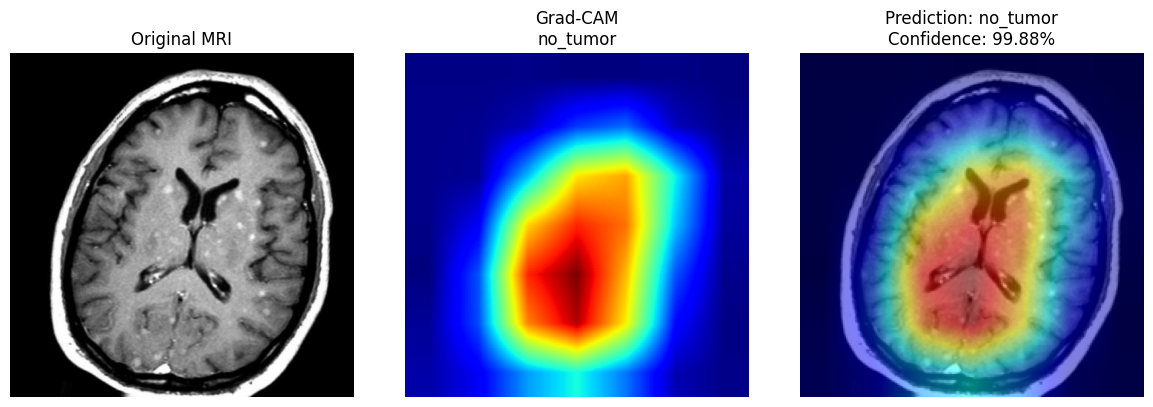

True: no_tumor | Predicted: no_tumor


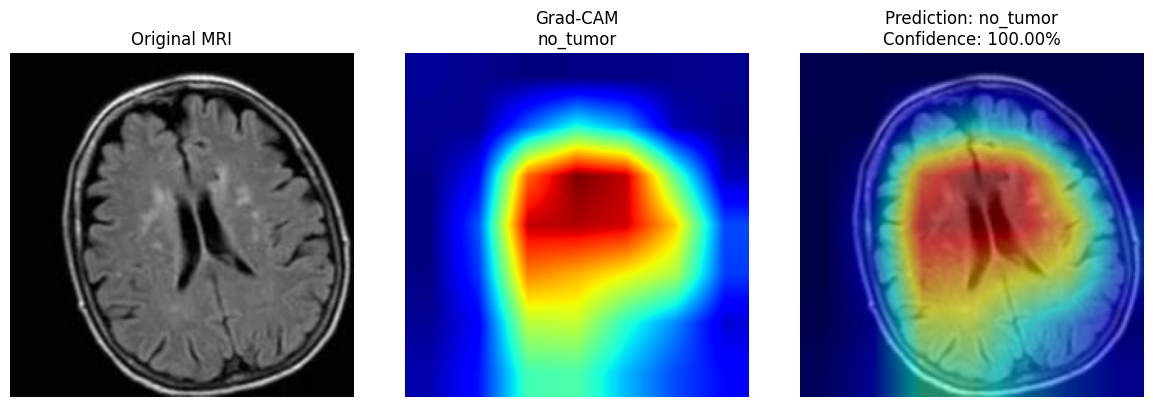

True: no_tumor | Predicted: no_tumor


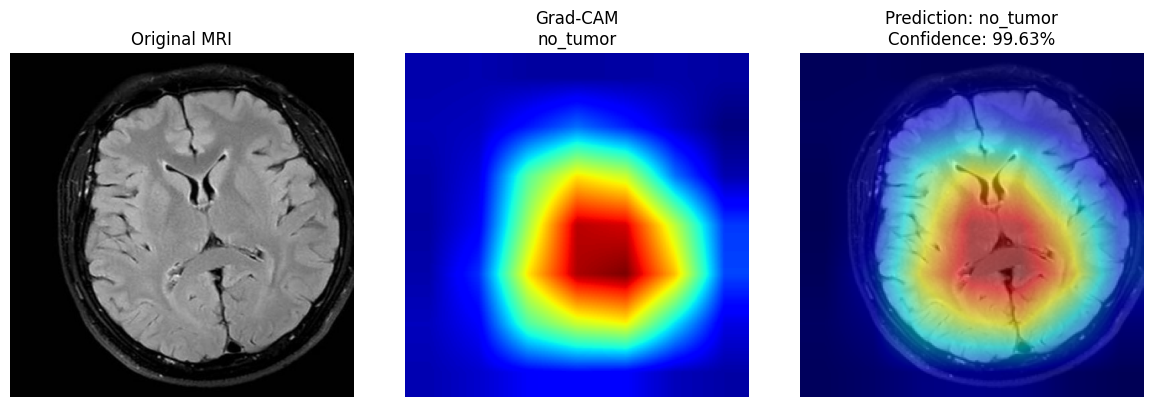

True: no_tumor | Predicted: no_tumor


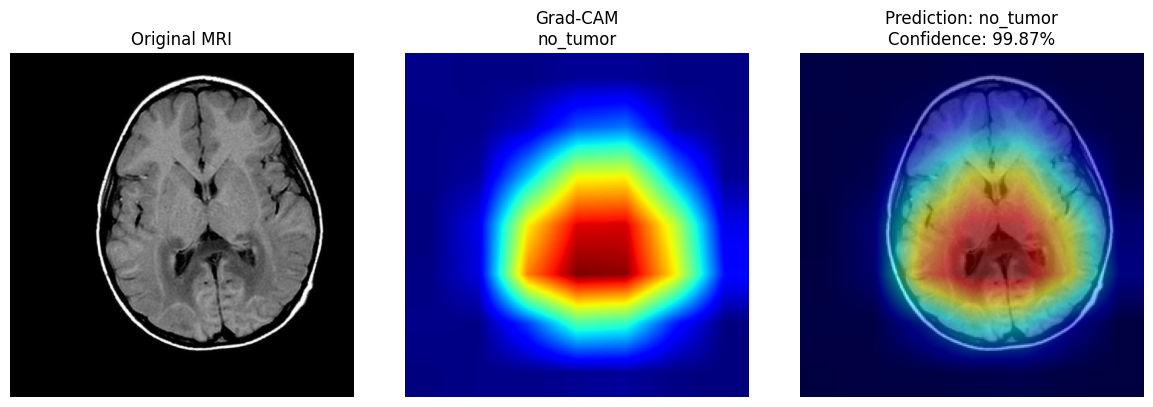

True: no_tumor | Predicted: no_tumor


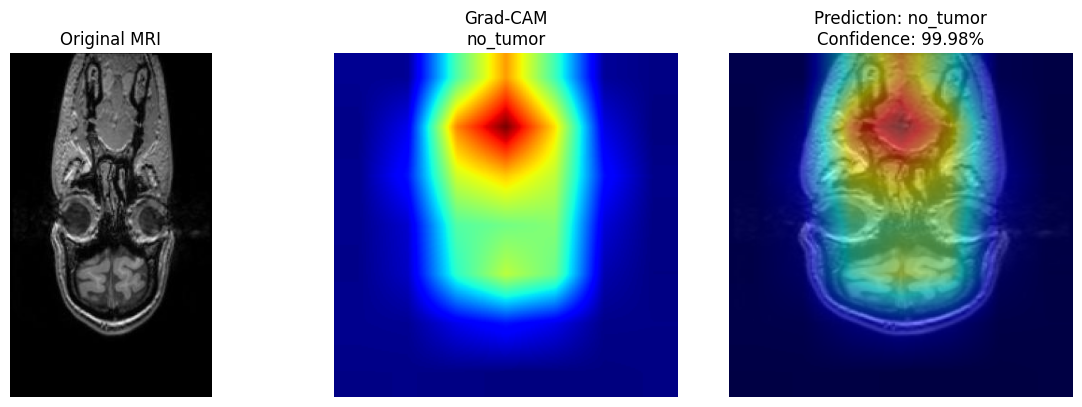

In [15]:
correct_indices = [
    i for i, (label, pred) in enumerate(zip(all_labels, all_predictions)) 
    if label == pred
]

print(f"Nombre total d'images correctement prédites : {len(correct_indices)}")

for index in correct_indices[600:605]:
    correct_class_idx = all_labels[index] 
    print(f"True: {CLASSES[all_labels[index]]} | Predicted: {CLASSES[all_predictions[index]]}")

    show_gradcam(model, test_image_paths[index], val_test_transform, CLASSES, cam)
    
 

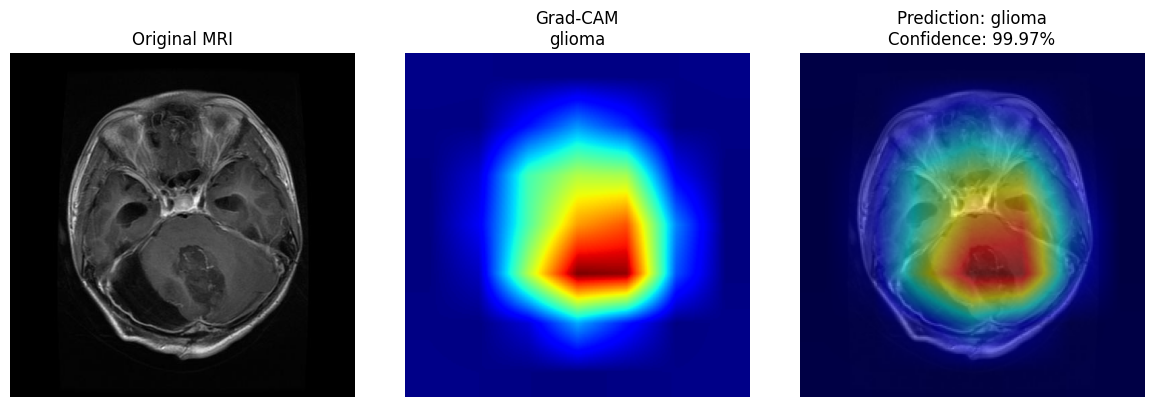

True: glioma | Predicted: meningioma


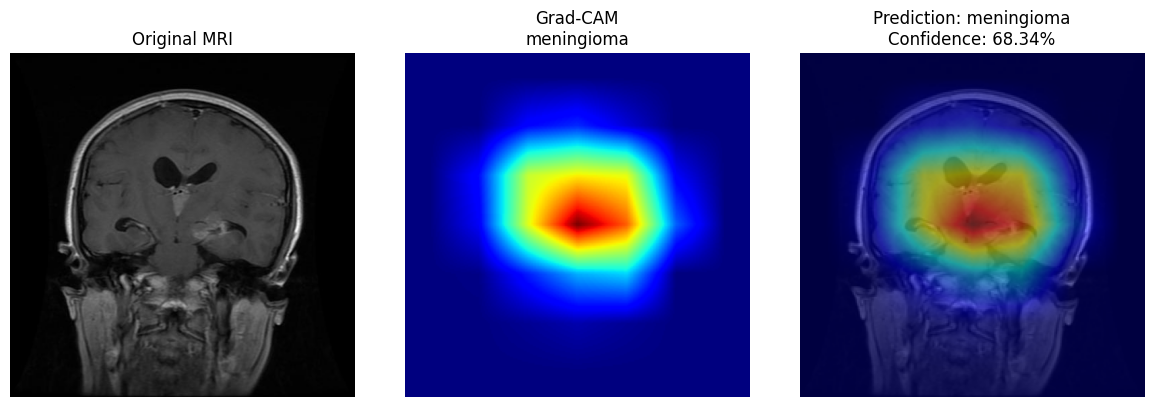

True: glioma | Predicted: meningioma


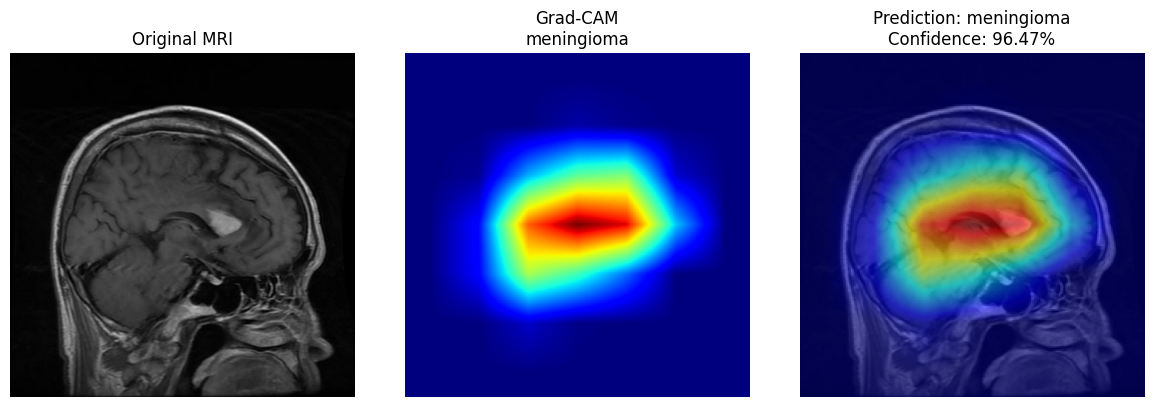

True: glioma | Predicted: meningioma


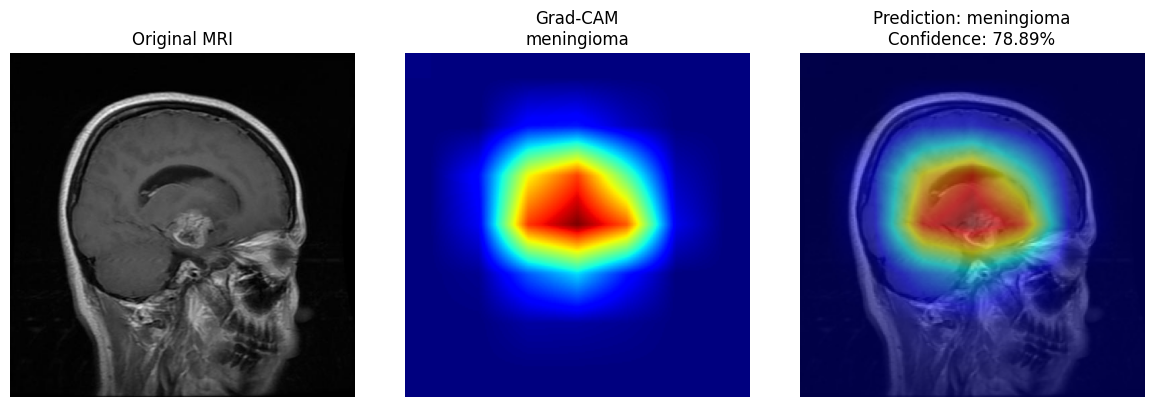

True: glioma | Predicted: meningioma


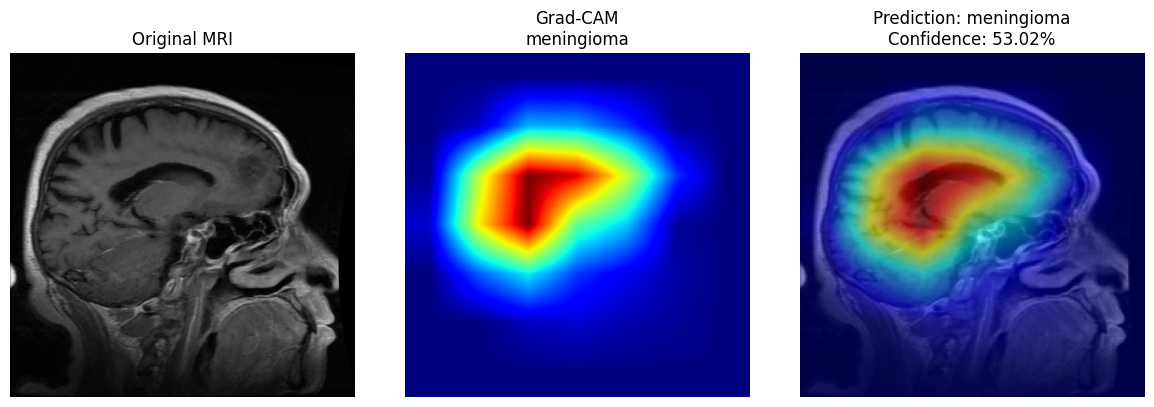

True: meningioma | Predicted: glioma


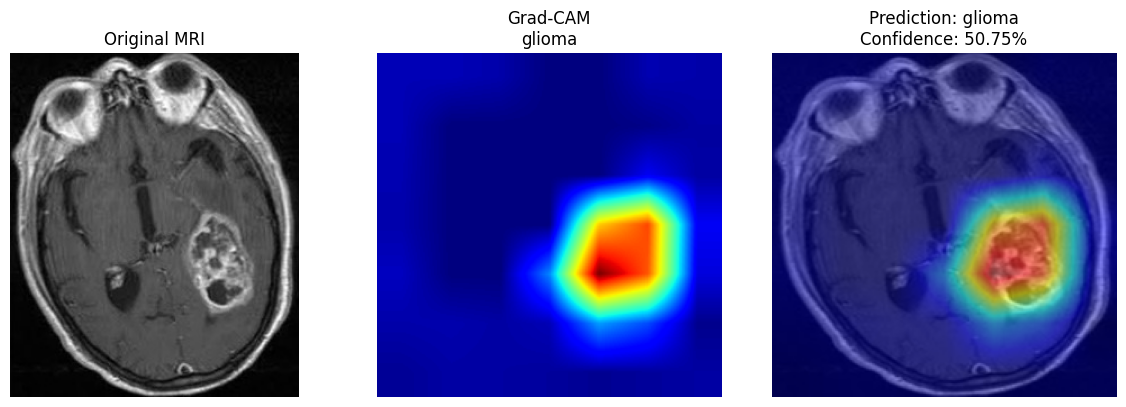

In [16]:
show_gradcam(model, test_image_paths[0], val_test_transform, CLASSES, cam)

for index in wrong_indices[:5]:
    print(f"True: {CLASSES[all_labels[index]]} | Predicted: {CLASSES[all_predictions[index]]}")
    show_gradcam(model, test_image_paths[index], val_test_transform, CLASSES, cam)

In [17]:

dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model.eval(), 
    dummy_input, 
    "efficientnet_b0_production.onnx", 
    export_params=True,
    opset_version=15,  
    do_constant_folding=True,
    input_names=['input'], 
    output_names=['output'],
    dynamo=False 
)
print("Exportation terminée.")


C:\Users\Emine Rae\AppData\Local\Temp\ipykernel_2544\768330854.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Exportation terminée.


In [18]:
import onnx

onnx_model = onnx.load("efficientnet_b0_production.onnx")

try:
    onnx.checker.check_model(onnx_model)
    print("Le modèle ONNX est parfaitement valide et prêt pour la production !")
except onnx.checker.ValidationError as e:
    print(f"Le modèle ONNX présente une erreur de structure : {e}")


Le modèle ONNX est parfaitement valide et prêt pour la production !
